# AG-HYPOPT · Trial 04

> ▶ RUN = execute this cell, never modify it  ·  ✍️ WRITE = replace the [placeholder] with your text  ·  ✍️ SET = put your value where the [placeholder] is, then run the cell. Full rules: `instructions.md`


## 1. ✍️ WRITE - Read and summarize

Read `context.md` (physics/model knowledge). If there are previous trials, read them too
(all `trial_XX` notebooks numbered lower than this one) and `trials.json` (the registry).
The current best is the recorded trial with the lowest objective; it is the reference
for the cell-3 choice.

Campaign state at trial_04. Three trials recorded, all at comparable/moderate bandwidth:

- trial_01 = target, h_f 5.349, h_s 7.652 -> 0.0837 (best so far).
- trial_02 = sim, h_f 5.308, h_s 3.060 -> 0.1249 (gamma collapse on low-count cells).
- trial_03 = power, h_f 8.658, h_s 4.220 -> 0.1541 (mu overshoot on low-count cells).

Current best is trial_01 (0.0837); the inherited exp6 reference is target, h_f 4.0, h_s 3.675 ->
0.0803. Ordering target < sim < power: the rule is a first-order lever and target leads. Target's
optimum is not yet pinned down - exp6 (4.0) marginally beat trial_01 (5.35), so the good region is
around h_f ~4-5 with h_s a few units, but the tested points there are sparse.


In [ ]:
# 2. ▶ RUN - Propose candidate trials (AGHyperopt)
TRIAL_ID = 'trial_04'   # auto-stamped by the generator; do not edit
import os

EXPERIMENT_DIR = os.getcwd()
SPACE_PATH = os.path.join(EXPERIMENT_DIR, 'space.json')
TRIALS_PATH = os.path.join(EXPERIMENT_DIR, 'trials.json')

MAX_TRIALS = 30    # campaign cap: stop generating new trials after this many (None = unlimited)

from ag_hypopt import AGHyperopt, trial_seed

opt = AGHyperopt(seed=trial_seed(TRIAL_ID))   # per-trial seed: fresh draws every trial
opt.fit(SPACE_PATH, TRIALS_PATH)
proposed_trials = opt.propose_trials(10)


phase = uniform  (3/5 trials)
ID |     ei | params
 1 |      - | {"bandwidth_rule": "power", "h_f_scale": 6.624603080957978, "h_s_scale": 11.738680762784746}
 2 |      - | {"bandwidth_rule": "power", "h_f_scale": 1.8891962628516241, "h_s_scale": 7.680914151945326}
 3 |      - | {"bandwidth_rule": "target", "h_f_scale": 9.82091327684388, "h_s_scale": 2.9198059775843133}
 4 |      - | {"bandwidth_rule": "sim", "h_f_scale": 10.587988016064221, "h_s_scale": 6.98335540839848}
 5 |      - | {"bandwidth_rule": "sim", "h_f_scale": 6.248688762231269, "h_s_scale": 5.7354590550235445}
 6 |      - | {"bandwidth_rule": "power", "h_f_scale": 9.678413892987624, "h_s_scale": 11.825682999242336}
 7 |      - | {"bandwidth_rule": "power", "h_f_scale": 11.658261562478584, "h_s_scale": 11.219290265419614}
 8 |      - | {"bandwidth_rule": "sim", "h_f_scale": 2.954618443381792, "h_s_scale": 7.697367785290023}
 9 |      - | {"bandwidth_rule": "target", "h_f_scale": 11.37084047042084, "h_s_scale": 8.3222315866

## 3. ✍️ WRITE - Analyze and choose

Using the summary from cell 1 (previous trials + registry) and the candidate table from
cell 2, choose the ONE proposal that makes the most sense for the next trial. No hypothesis
and no expectation are needed: base the choice on what the trials have shown and on the
candidates themselves.

The rule comparison is effectively settled (target 0.0837 < sim 0.1249 < power 0.1541), so the useful
work now is to characterize the winning target rule's coefficient landscape, not to keep spending
trials on the two losing rules. The proposals offer only two `target` candidates: #3 (h_f 9.82, h_s
2.92) and #9 (h_f 11.37, h_s 8.32), both high h_f. Everything else is sim or power, which the first
three trials have already argued against at comparable scale.

Between the two target candidates, #3 is the more informative: it keeps h_s low (2.92, below exp6's
3.675) while pushing h_f high (9.82), so it cleanly probes the upper-h_f end of the winning rule with a
sigma channel that is not simultaneously flattened. #9 moves both coefficients up at once (11.37 and
8.32), which confounds the two effects and sits nearer the caps. #3 also tests whether the trial_01 ->
exp6 worsening with larger h_f continues, i.e. whether the target optimum really is below exp6's 4.0.

I choose candidate 3 (target, h_f_scale 9.821, h_s_scale 2.920).


In [ ]:
# 4. ✍️ SET - Chosen candidate (edit INDEX below, then run this cell)
INDEX = 3            # [Put the index here: 1-based candidate number from the table in cell 2]


chosen: {'bandwidth_rule': 'target', 'h_f_scale': 9.82091327684388, 'h_s_scale': 2.9198059775843133}
Running  1nW Trans05 ... 

μ 9.39 -> 4.96 | γ 8.5 -> 4.68 | NLL 0.22


Running  1nW Trans20 ... 

μ 17.32 -> 19.54 | γ 8.5 -> 4.68 | NLL 0.49


Running  1nW Trans60 ... 

...

Running  3nW Trans60 ... 

μ 103.20 -> 62.63 | γ 14.1 -> 12.70 | NLL 0.42


Running 3nW Trans100 ... 

μ 175.71 -> 97.73 | γ 14.1 -> 12.80 | NLL 0.39



Total: 7.3 min


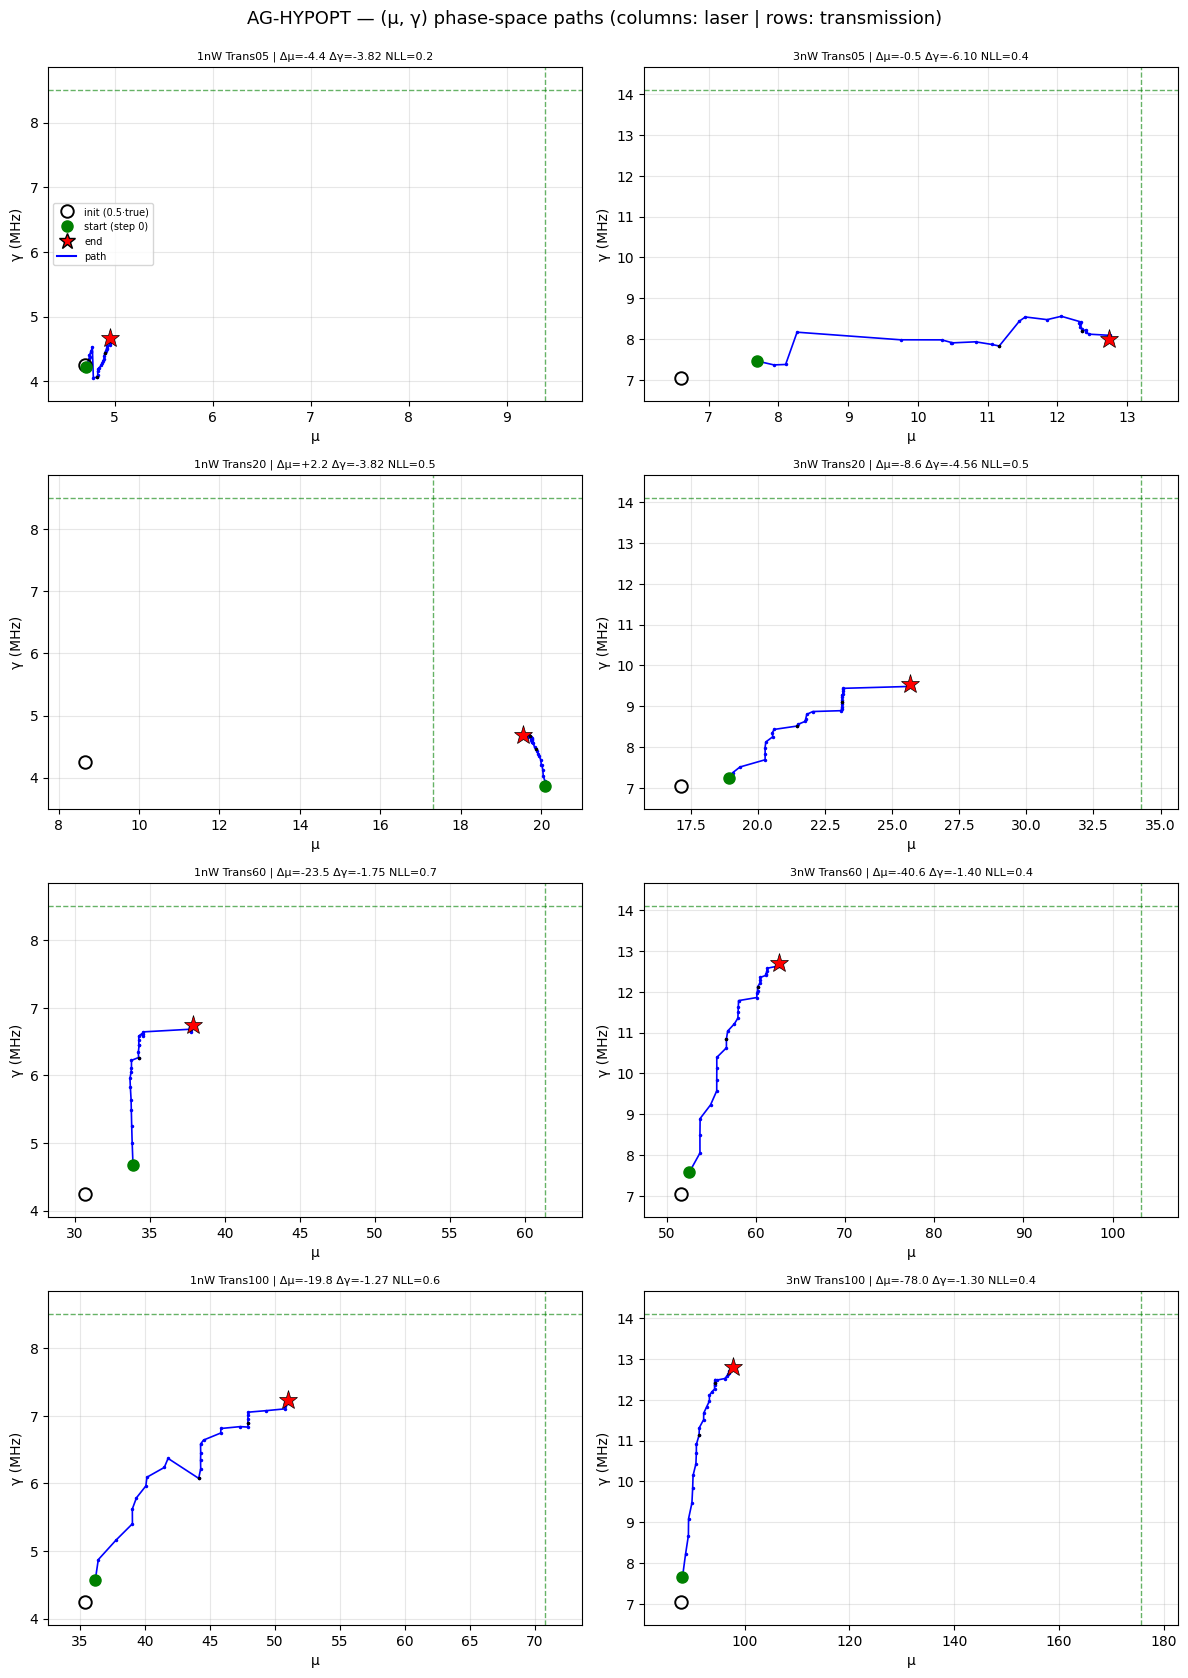

trial finished in 7.4 min
objective = 0.0926 ± 0.0207
exp              μ_true   μ_fit     Δμ% |   γ_true   γ_fit     Δγ%
1nW Trans05        9.39    4.96   -47.2 |     8.50    4.68   -45.0
1nW Trans20       17.32   19.54   +12.8 |     8.50    4.68   -44.9
1nW Trans60       61.37   37.91   -38.2 |     8.50    6.75   -20.6
1nW Trans100       70.82   51.01   -28.0 |     8.50    7.23   -14.9
3nW Trans05       13.20   12.75    -3.5 |    14.10    8.00   -43.2
3nW Trans20       34.28   25.68   -25.1 |    14.10    9.54   -32.3
3nW Trans60      103.20   62.63   -39.3 |    14.10   12.70    -9.9
3nW Trans100      175.71   97.73   -44.4 |    14.10   12.80    -9.2

weighted objective (T-graded, cap=1.0) = 0.0926 | diverged cells: 0
μ: RMSE 33.108 (rel 33.2%, bias -21.638) | γ: RMSE 3.455 (rel 31.2%, bias -3.003)


TypeError: unsupported operand type(s) for -: 'str' and 'str'

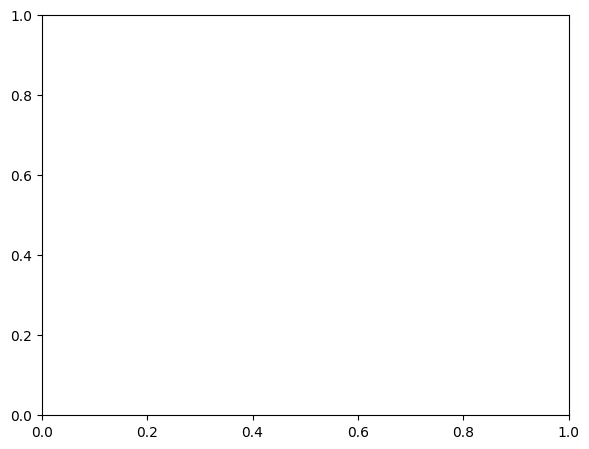

In [ ]:
# 5. ▶ RUN - Execute the chosen trial  (do not interrupt unless obviously broken)
assert INDEX is not None, 'INDEX not set: edit the SET cell (cell 4) before running this one'
assert 1 <= INDEX <= len(proposed_trials), f'bad INDEX: {INDEX}'
CHOSEN = proposed_trials[INDEX - 1]['params']
print('chosen:', CHOSEN)

from ag_hypopt import objective

import traceback, time
t0 = time.time()
try:
    loss, uncertainty, report = objective(CHOSEN)
    print(f'trial finished in {(time.time()-t0)/60:.1f} min')
    print(f'objective = {loss:.4f} ± {uncertainty:.4f}')
    print(report)
except Exception:
    traceback.print_exc()
    loss, uncertainty = None, None

# parallel coordinates: every recorded trial + this one (color = objective)
from ag_hypopt import plot_parallel
if loss is not None:
    plot_parallel(TRIALS_PATH, current={'config': CHOSEN, 'objective': loss})


## 6. ✍️ WRITE - Analyze the results

Record what actually happened in this trial: the measured objective, how the chosen
configuration behaved, and how that compares with the previous trials. No hypothesis to
confirm or refute, and no expectation to check: just the facts.

Objective = 0.0926 ± 0.0207, gamma finite on all 8 cells, diverged cells: 0. Config: bandwidth_rule =
target, h_f_scale = 9.821, h_s_scale = 2.920.

This is worse than trial_01 (0.0837). mu rel-RMSE is similar in character (underestimated in 7 of 8
cells, -25 to -47 %, with 1nW Trans20 the lone overshoot at +12.8 %), and gamma is again
underestimated everywhere (-9 to -45 %), heavily in the low-count cells. Relative to trial_01 the
degradation shows up mainly at low T (1nW Trans05 gamma 4.68 vs 6.19; 1nW Trans20 gamma 4.68 vs 4.96).

The `target` rule now has a clean monotone trend in h_f on the same benchmark: objective 0.0803 at
h_f 4.0 (exp6), 0.0837 at h_f 5.35 (trial_01), 0.0926 at h_f 9.82 (this trial). So on the target rule the
objective RISES with h_f above exp6's 4.0 - the exp6 optimum was already at/near the target-rule
optimum, and extending the bound to 12 does not help that rule. (This trial also lowered h_s from
7.65 to 2.92 while raising h_f, so the two effects are partly confounded, but the h_f trend is the
dominant and consistent one.) Overall ranking so far: target 4.0 (0.0803) < target 5.35 (0.0837) <
target 9.82 (0.0926) < sim 5.31 (0.1249) < power 8.66 (0.1541).

Execution note: same trailing `plot_parallel` diagnostic TypeError (2 traces in the log); the
objective was computed and printed first, so the trial stands. No rerun.

**Summary:** Trial 4 (target rule, h_f 9.821, h_s 2.920) scores objective 0.0926 ± 0.0207, worse than trial_01 (0.0837), extending the target rule further above exp6's optimum on the wrong side.
**Key insight:** On the target rule the objective rises monotonically with h_f above ~4 (0.0803 @4.0, 0.0837 @5.35, 0.0926 @9.82), so exp6's h_f = 4.0 already sat at the target-rule optimum and the extended upper bound buys nothing for this rule.

Notes for Anuar (optional, not acted on): the monotone h_f trend for the target rule suggests the real
remaining headroom is BELOW h_f ~4, not above it - something the current proposal stream has not offered
yet for the target rule.


In [ ]:
# 7. ✍️ SET - Summary and key insight for the record (edit the strings below, then run)
SUMMARY = "Trial 4 (target rule, h_f 9.821, h_s 2.920) scores objective 0.0926 ± 0.0207, worse than trial_01 (0.0837), extending the target rule further above exp6's optimum on the wrong side."      # [Put the one-line summary here: copy it from cell 6]
KEY_INSIGHT = "On the target rule the objective rises monotonically with h_f above ~4 (0.0803 @4.0, 0.0837 @5.35, 0.0926 @9.82), so exp6's h_f = 4.0 already sat at the target-rule optimum and the extended upper bound buys nothing for this rule."  # [Put the one-sentence key insight here: copy it from cell 6]


In [ ]:
# 8. ▶ RUN - Record the trial in trials.json
import json

assert SUMMARY is not None, 'SUMMARY not set: fill the SET cell (cell 7) first'
assert KEY_INSIGHT is not None, 'KEY_INSIGHT not set: fill the SET cell (cell 7) first'

entry = {
    'trial_id': TRIAL_ID,
    'config': CHOSEN,
    'objective': loss,
    'uncertainty': uncertainty,
    'summary': SUMMARY,
    'key_insight': KEY_INSIGHT,
    'notebook': f'{TRIAL_ID}.ipynb',
}
data = json.load(open(TRIALS_PATH))
assert not any(t.get('trial_id') == TRIAL_ID for t in data['trials']),     f'{TRIAL_ID} is already registered in trials.json'
data['trials'].append(entry)
json.dump(data, open(TRIALS_PATH, 'w'), indent=2)
best = min((t for t in data['trials'] if t.get('objective') is not None),
           key=lambda t: t['objective'], default=None)
print('saved', TRIAL_ID, '| current best:', best['trial_id'] if best else None)


saved trial_04 | current best: trial_01


In [ ]:
# 9. ▶ RUN - Generate the next trial (or end the campaign)
import os, re, json as _json

num = int(re.search(r'(\d+)$', TRIAL_ID).group(1))
nxt = num + 1
if MAX_TRIALS is not None and nxt > MAX_TRIALS:
    print(f'Campaign complete: cap MAX_TRIALS={MAX_TRIALS} reached after {TRIAL_ID}. Stop here.')
else:
    template_path = os.path.join(EXPERIMENT_DIR, 'template.ipynb')
    target = os.path.join(EXPERIMENT_DIR, f'trial_{nxt:02d}.ipynb')
    assert not os.path.exists(target), f'{target} already exists: refusing to overwrite'

    nb = _json.load(open(template_path))

    def _stamp(old, new):
        for c in nb['cells']:
            if old in ''.join(c.get('source', [])):
                c['source'] = [s.replace(old, new) for s in c['source']]
                return True
        raise RuntimeError(f'stamp target {old!r} not found in the template')

    _stamp('{N}', f'{nxt:02d}')
    _stamp('trial_XXX', f'trial_{nxt:02d}')
    _json.dump(nb, open(target, 'w'), indent=1)
    print(f'Created {os.path.basename(target)}. Open it and follow its cells from the top.')


Created trial_05.ipynb. Open it and follow its cells from the top.
